# MedRE-Bench: Dataset Exploration (Sentence-Level)

After the preprocessing refactor, each `RelationExample` corresponds to a single **sentence × (entity1, entity2)** pair. Sentences with entity pairs but no annotated relation are emitted as `NO_RELATION` (or the dataset's native negative label).

Sections:
1. Split sizes (train / validation / test) — pair-level samples
2. Distinct sentences and pairs-per-sentence stats
3. Character / word / token length distributions
4. Class distribution (with negatives highlighted)
5. Class balance after random oversampling
6. Class balance after **Tomek Links** cleaning + ROS hybrid
7. Preprocessed text with entity markers

In [1]:
import sys
sys.path.insert(0, "../src")

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from collections import Counter, defaultdict

from medre_bench.datasets.base import apply_entity_markers
from medre_bench.datasets.preprocessing import random_oversample, clean_with_tomek
from medre_bench.registry import DATASET_REGISTRY
import medre_bench.datasets  # trigger registration

plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

DATASET_NAMES = [
    "chemprot",
    "drugprot",
    "biored",
    "bc5cdr",
    "ddi",
    "gad",
    "euadr",
    "chem_dis_gene",
]

NEGATIVE_LABELS = {
    "chemprot": "Not",
    "drugprot": "NO_RELATION",
    "biored": "NO_RELATION",
    "bc5cdr": "No_Relation",
    "ddi": "NO_RELATION",
    "gad": "0",
    "euadr": "NA",
    "chem_dis_gene": "NO_RELATION",
}

print(f"Registered datasets: {list(DATASET_REGISTRY._registry.keys())}")

Registered datasets: ['bc5cdr', 'biored', 'chem_dis_gene', 'chemprot', 'ddi', 'drugprot', 'euadr', 'gad']


## 1. Load All Splits

In [2]:
all_data = {}

for ds_name in DATASET_NAMES:
    print(f"Loading {ds_name}...", end=" ", flush=True)
    ds_cls = DATASET_REGISTRY.get(ds_name)
    ds = ds_cls()
    splits = {}
    for split in ["train", "validation", "test"]:
        try:
            examples = ds.load_split(split)
            splits[split] = examples
        except (ValueError, KeyError):
            splits[split] = None
    all_data[ds_name] = {"splits": splits, "instance": ds}
    loaded = {k: len(v) for k, v in splits.items() if v is not None}
    print(f"done — {loaded}")

print("\nAll datasets loaded.")

Loading chemprot... done — {'train': 77252, 'validation': 46502, 'test': 64632}
Loading drugprot... done — {'train': 272918, 'validation': 56366}
Loading biored... done — {'train': 43038, 'validation': 11567, 'test': 11624}
Loading bc5cdr... done — {'train': 22396, 'validation': 23314, 'test': 23102}
Loading ddi... done — {'train': 32512, 'validation': 5737, 'test': 9594}
Loading gad... done — {'train': 4077, 'validation': 719, 'test': 534}
Loading euadr... done — {'train': 16431, 'validation': 3520, 'test': 3520}
Loading chem_dis_gene... done — {'train': 27782, 'validation': 5952, 'test': 5952}

All datasets loaded.


## 2. Split Sizes (Pair-Level Samples)

In [3]:
summary_rows = []
for ds_name in DATASET_NAMES:
    info = all_data[ds_name]
    ds = info["instance"]
    splits = info["splits"]
    train_n = len(splits["train"]) if splits["train"] else 0
    val_n = len(splits["validation"]) if splits["validation"] else 0
    test_n = len(splits["test"]) if splits["test"] else 0

    all_examples = []
    for s in splits.values():
        if s:
            all_examples.extend(s)
    distinct_sentences = len({ex.text for ex in all_examples}) if all_examples else 0

    summary_rows.append({
        "Dataset": ds_name,
        "Train Pairs": train_n,
        "Val Pairs": val_n,
        "Test Pairs": test_n,
        "Total Pairs": train_n + val_n + test_n,
        "Distinct Sentences": distinct_sentences,
        "Avg Pairs/Sent": round((train_n + val_n + test_n) / max(distinct_sentences, 1), 2),
        "# Labels": ds.num_labels(),
        "Negative Label": NEGATIVE_LABELS.get(ds_name, ""),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,Dataset,Train Pairs,Val Pairs,Test Pairs,Total Pairs,Distinct Sentences,Avg Pairs/Sent,# Labels,Negative Label
0,chemprot,77252,46502,64632,188386,14846,12.69,6,Not
1,drugprot,272918,56366,0,329284,25885,12.72,14,NO_RELATION
2,biored,43038,11567,11624,66229,4938,13.41,9,NO_RELATION
3,bc5cdr,22396,23314,23102,68812,8377,8.21,2,No_Relation
4,ddi,32512,5737,9594,47843,4506,10.62,5,NO_RELATION
5,gad,4077,719,534,5330,5122,1.04,2,0
6,euadr,16431,3520,3520,23471,1892,12.41,3,NA
7,chem_dis_gene,27782,5952,5952,39686,3791,10.47,19,NO_RELATION


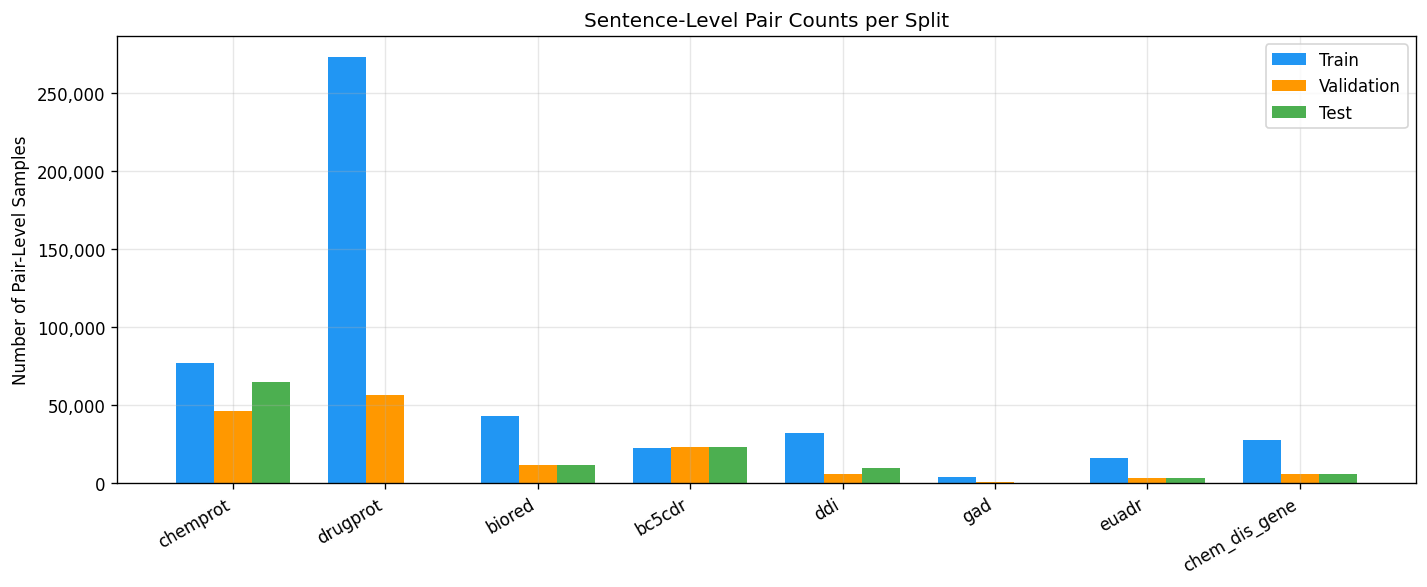

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(DATASET_NAMES))
width = 0.25

train_counts = [len(all_data[d]["splits"]["train"] or []) for d in DATASET_NAMES]
val_counts = [len(all_data[d]["splits"]["validation"] or []) for d in DATASET_NAMES]
test_counts = [len(all_data[d]["splits"]["test"] or []) for d in DATASET_NAMES]

ax.bar(x - width, train_counts, width, label="Train", color="#2196F3")
ax.bar(x, val_counts, width, label="Validation", color="#FF9800")
ax.bar(x + width, test_counts, width, label="Test", color="#4CAF50")

ax.set_xticks(x)
ax.set_xticklabels(DATASET_NAMES, rotation=30, ha="right")
ax.set_ylabel("Number of Pair-Level Samples")
ax.set_title("Sentence-Level Pair Counts per Split")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
plt.tight_layout()
plt.show()

## 3. Sentence-Level Statistics

In [5]:
sentence_stats_rows = []
pairs_per_sentence_data = {}

for ds_name in DATASET_NAMES:
    examples = all_data[ds_name]["splits"]["train"]
    if not examples:
        continue

    pairs_per_sent = defaultdict(int)
    for ex in examples:
        pairs_per_sent[ex.text] += 1

    counts = list(pairs_per_sent.values())
    pairs_per_sentence_data[ds_name] = counts

    sentence_stats_rows.append({
        "Dataset": ds_name,
        "# Sentences (train)": f"{len(counts):,}",
        "# Pairs (train)": f"{sum(counts):,}",
        "Pairs/Sent Mean": f"{np.mean(counts):.2f}",
        "Pairs/Sent Median": f"{np.median(counts):.0f}",
        "Pairs/Sent Max": f"{np.max(counts):,}",
        "Single-pair Sents": f"{sum(1 for c in counts if c == 1):,} ({sum(1 for c in counts if c == 1)/len(counts)*100:.1f}%)",
    })

pd.DataFrame(sentence_stats_rows)

,Dataset,# Sentences (train),# Pairs (train),Pairs/Sent Mean,Pairs/Sent Median,Pairs/Sent Max,Single-pair Sents
0,chemprot,"6,221","77,252",12.42,6,50,0 (0.0%)
1,drugprot,"21,376","272,918",12.77,6,84,0 (0.0%)
2,biored,"3,247","43,038",13.25,6,74,0 (0.0%)
3,bc5cdr,"2,722","22,396",8.23,6,50,0 (0.0%)
4,ddi,"3,561","32,512",9.13,5,131,361 (10.1%)
5,gad,"3,948","4,077",1.03,1,4,"3,824 (96.9%)"
6,euadr,"1,836","16,431",8.95,5,42,246 (13.4%)
7,chem_dis_gene,"3,671","27,782",7.57,5,42,608 (16.6%)


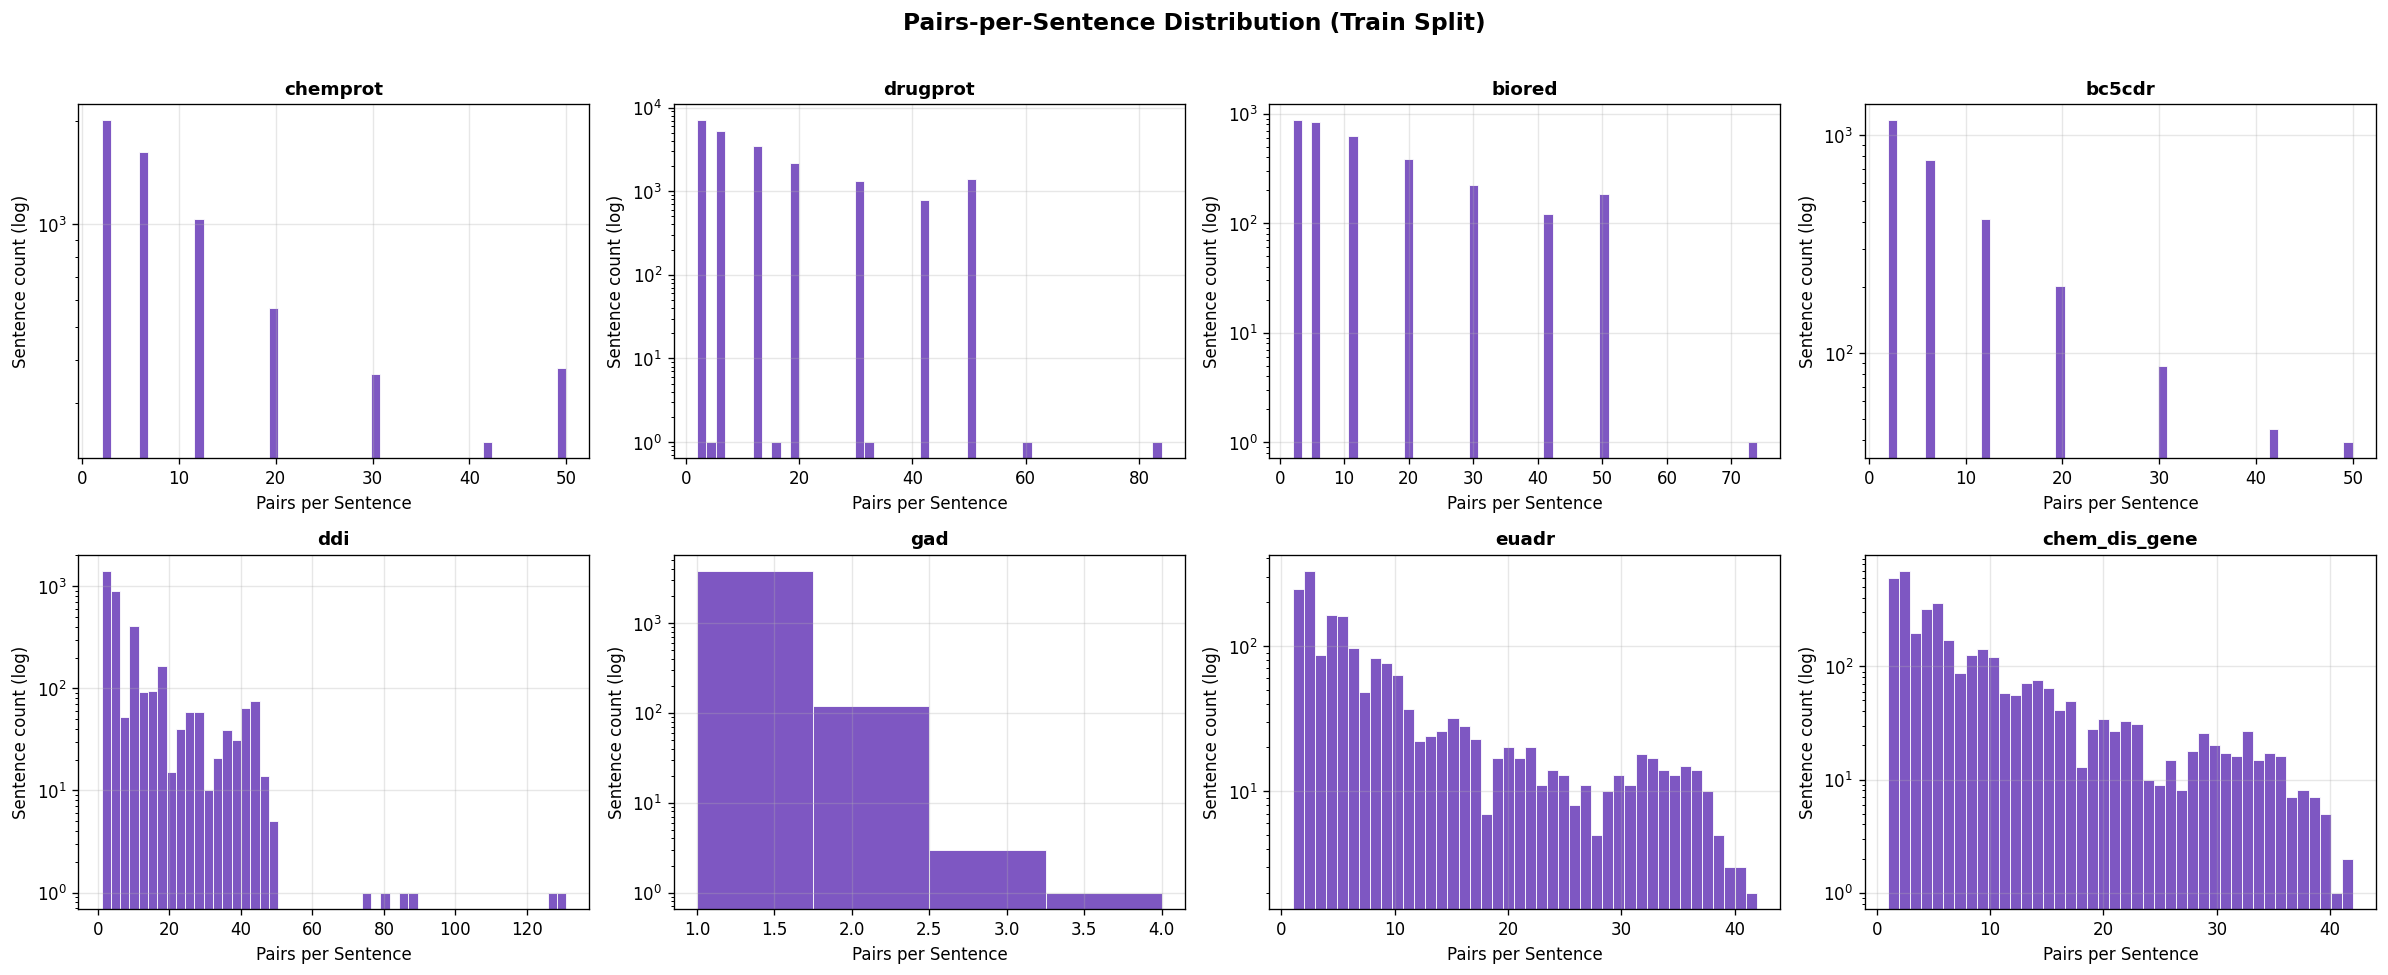

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for idx, ds_name in enumerate(DATASET_NAMES):
    ax = axes[idx]
    if ds_name not in pairs_per_sentence_data:
        ax.set_visible(False)
        continue
    counts = pairs_per_sentence_data[ds_name]
    bins = min(50, max(counts))
    ax.hist(counts, bins=bins, color="#7E57C2", edgecolor="white", linewidth=0.5)
    ax.set_yscale("log")
    ax.set_title(ds_name, fontsize=11, fontweight="bold")
    ax.set_xlabel("Pairs per Sentence")
    ax.set_ylabel("Sentence count (log)")

for idx in range(len(DATASET_NAMES), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("Pairs-per-Sentence Distribution (Train Split)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 4. Length Analysis: Characters, Words, Tokens

In [6]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext")
print(f"Using tokenizer: {tokenizer.name_or_path} (vocab size: {tokenizer.vocab_size:,})")

Using tokenizer: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext (vocab size: 30,522)


In [7]:
length_stats_rows = []
char_data = {}
word_data = {}
token_data = {}

for ds_name in DATASET_NAMES:
    examples = all_data[ds_name]["splits"]["train"]
    if not examples:
        continue

    unique_sentences = list({ex.text for ex in examples})

    char_lengths = [len(t) for t in unique_sentences]
    word_lengths = [len(t.split()) for t in unique_sentences]
    token_lengths = [len(tokenizer.encode(t, add_special_tokens=True)) for t in unique_sentences]

    char_data[ds_name] = char_lengths
    word_data[ds_name] = word_lengths
    token_data[ds_name] = token_lengths

    length_stats_rows.append({
        "Dataset": ds_name,
        "# Unique Sents": f"{len(unique_sentences):,}",
        "Char Mean": f"{np.mean(char_lengths):.0f}",
        "Char Median": f"{np.median(char_lengths):.0f}",
        "Char Max": f"{np.max(char_lengths):,}",
        "Word Mean": f"{np.mean(word_lengths):.0f}",
        "Word Max": f"{np.max(word_lengths):,}",
        "Token Mean": f"{np.mean(token_lengths):.0f}",
        "Token Median": f"{np.median(token_lengths):.0f}",
        "Token 95th": f"{np.percentile(token_lengths, 95):.0f}",
        "Token Max": f"{np.max(token_lengths):,}",
        "> 512 toks (%)": f"{sum(1 for t in token_lengths if t > 512)/len(token_lengths)*100:.1f}%",
    })

pd.DataFrame(length_stats_rows)

,Dataset,# Unique Sents,Char Mean,Char Median,Char Max,Word Mean,Word Max,Token Mean,Token Median,Token 95th,Token Max,> 512 toks (%)
0,chemprot,"6,221",178,165,870,25,116,40,35,74,314,0.0%
1,drugprot,"21,376",180,166,"1,451",25,200,40,35,75,550,0.0%
2,biored,"3,247",164,153,753,24,112,36,32,67,274,0.0%
3,bc5cdr,"2,722",161,149,677,23,92,34,30,64,184,0.0%
4,ddi,"3,561",177,158,"2,903",24,407,37,32,69,949,0.0%
5,gad,"3,948",173,162,538,26,81,38,35,59,126,0.0%
6,euadr,"1,836",169,158,754,24,116,36,32,69,257,0.0%
7,chem_dis_gene,"3,671",173,160,"2,021",24,244,37,33,67,468,0.0%


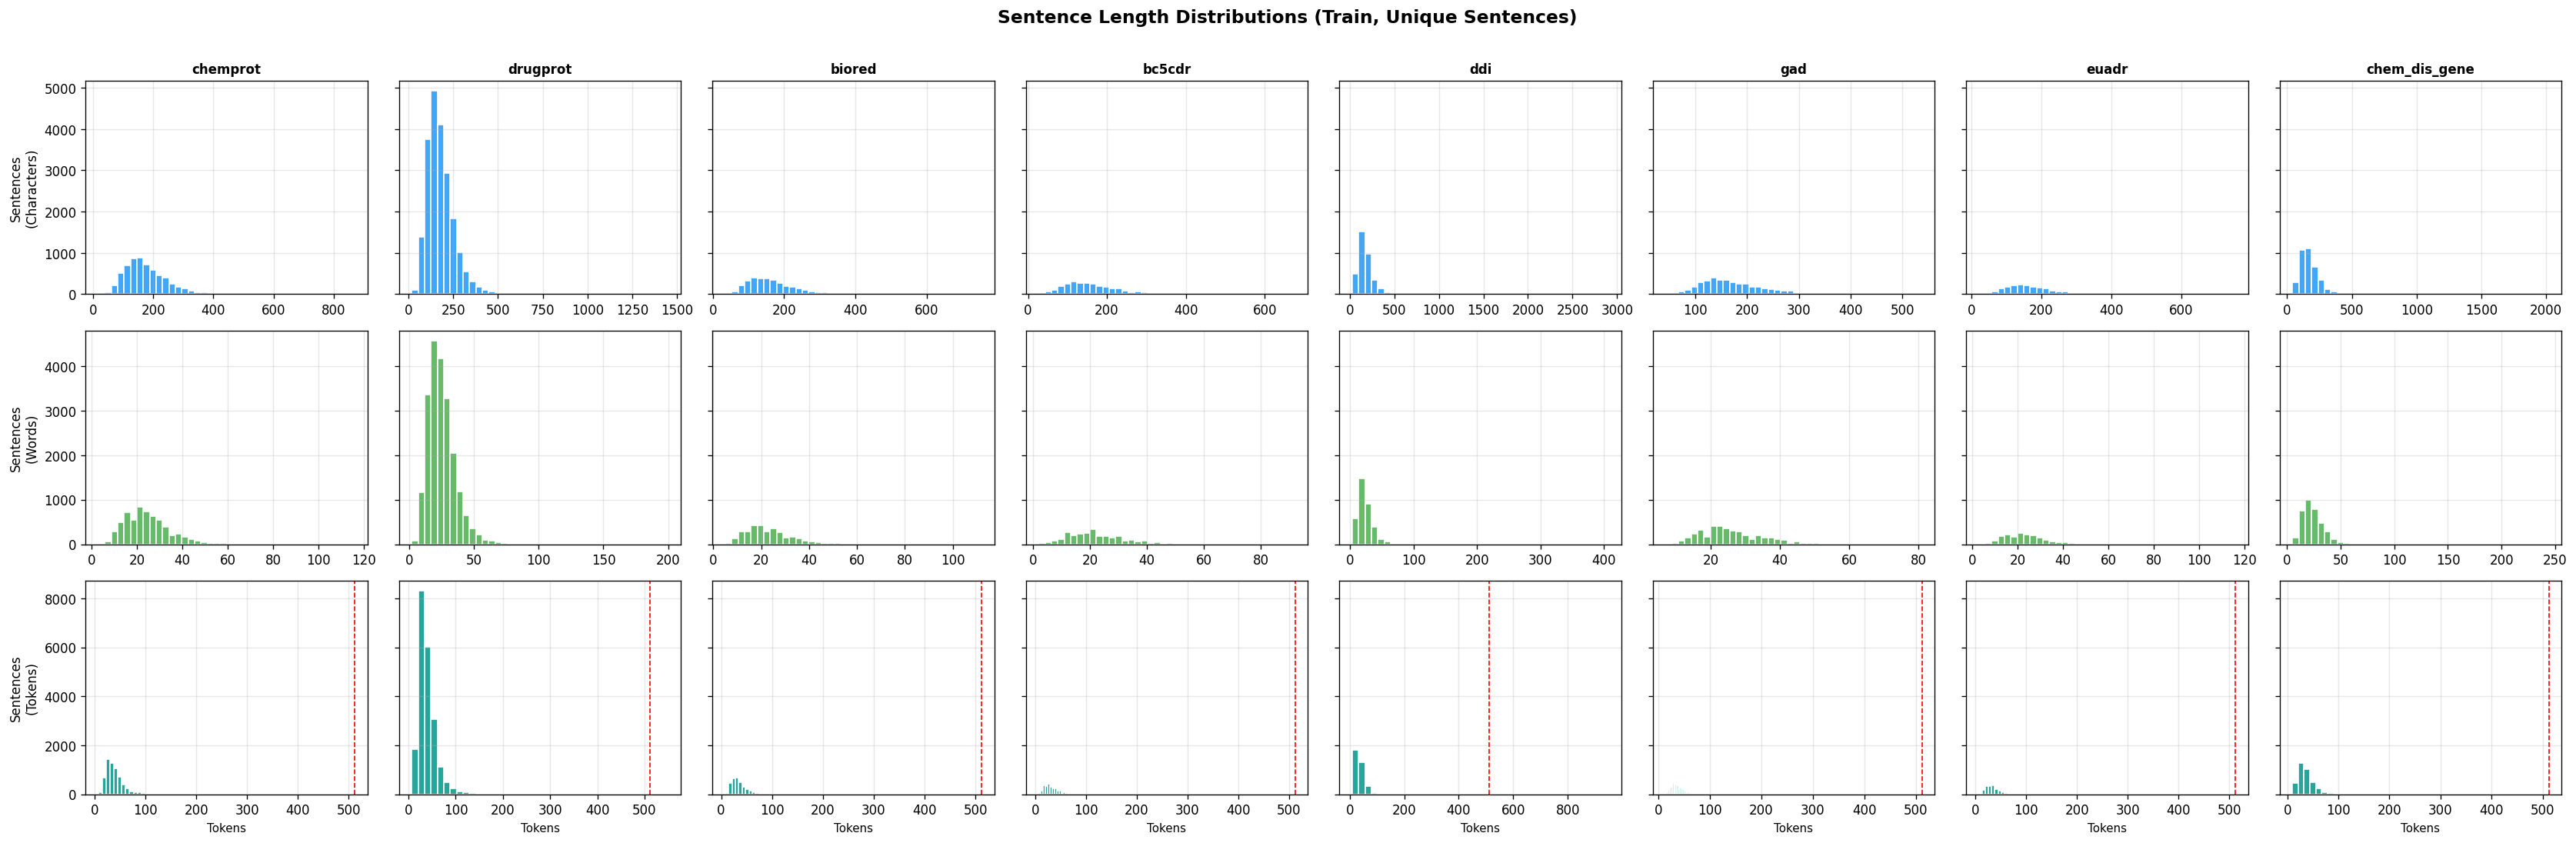

In [8]:
fig, axes = plt.subplots(3, len(DATASET_NAMES), figsize=(28, 9), sharey="row")

for col, ds_name in enumerate(DATASET_NAMES):
    if ds_name not in char_data:
        for row in range(3):
            axes[row, col].set_visible(False)
        continue

    axes[0, col].hist(char_data[ds_name], bins=40, color="#42A5F5", edgecolor="white")
    axes[0, col].set_title(ds_name, fontsize=10, fontweight="bold")

    axes[1, col].hist(word_data[ds_name], bins=40, color="#66BB6A", edgecolor="white")

    axes[2, col].hist(token_data[ds_name], bins=40, color="#26A69A", edgecolor="white")
    axes[2, col].axvline(x=512, color="red", linestyle="--", linewidth=1)
    axes[2, col].set_xlabel("Tokens", fontsize=9)

axes[0, 0].set_ylabel("Sentences\n(Characters)", fontsize=10)
axes[1, 0].set_ylabel("Sentences\n(Words)", fontsize=10)
axes[2, 0].set_ylabel("Sentences\n(Tokens)", fontsize=10)

fig.suptitle("Sentence Length Distributions (Train, Unique Sentences)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 5. Class Distribution (Natural Imbalance)

Negative class shown in **red**.

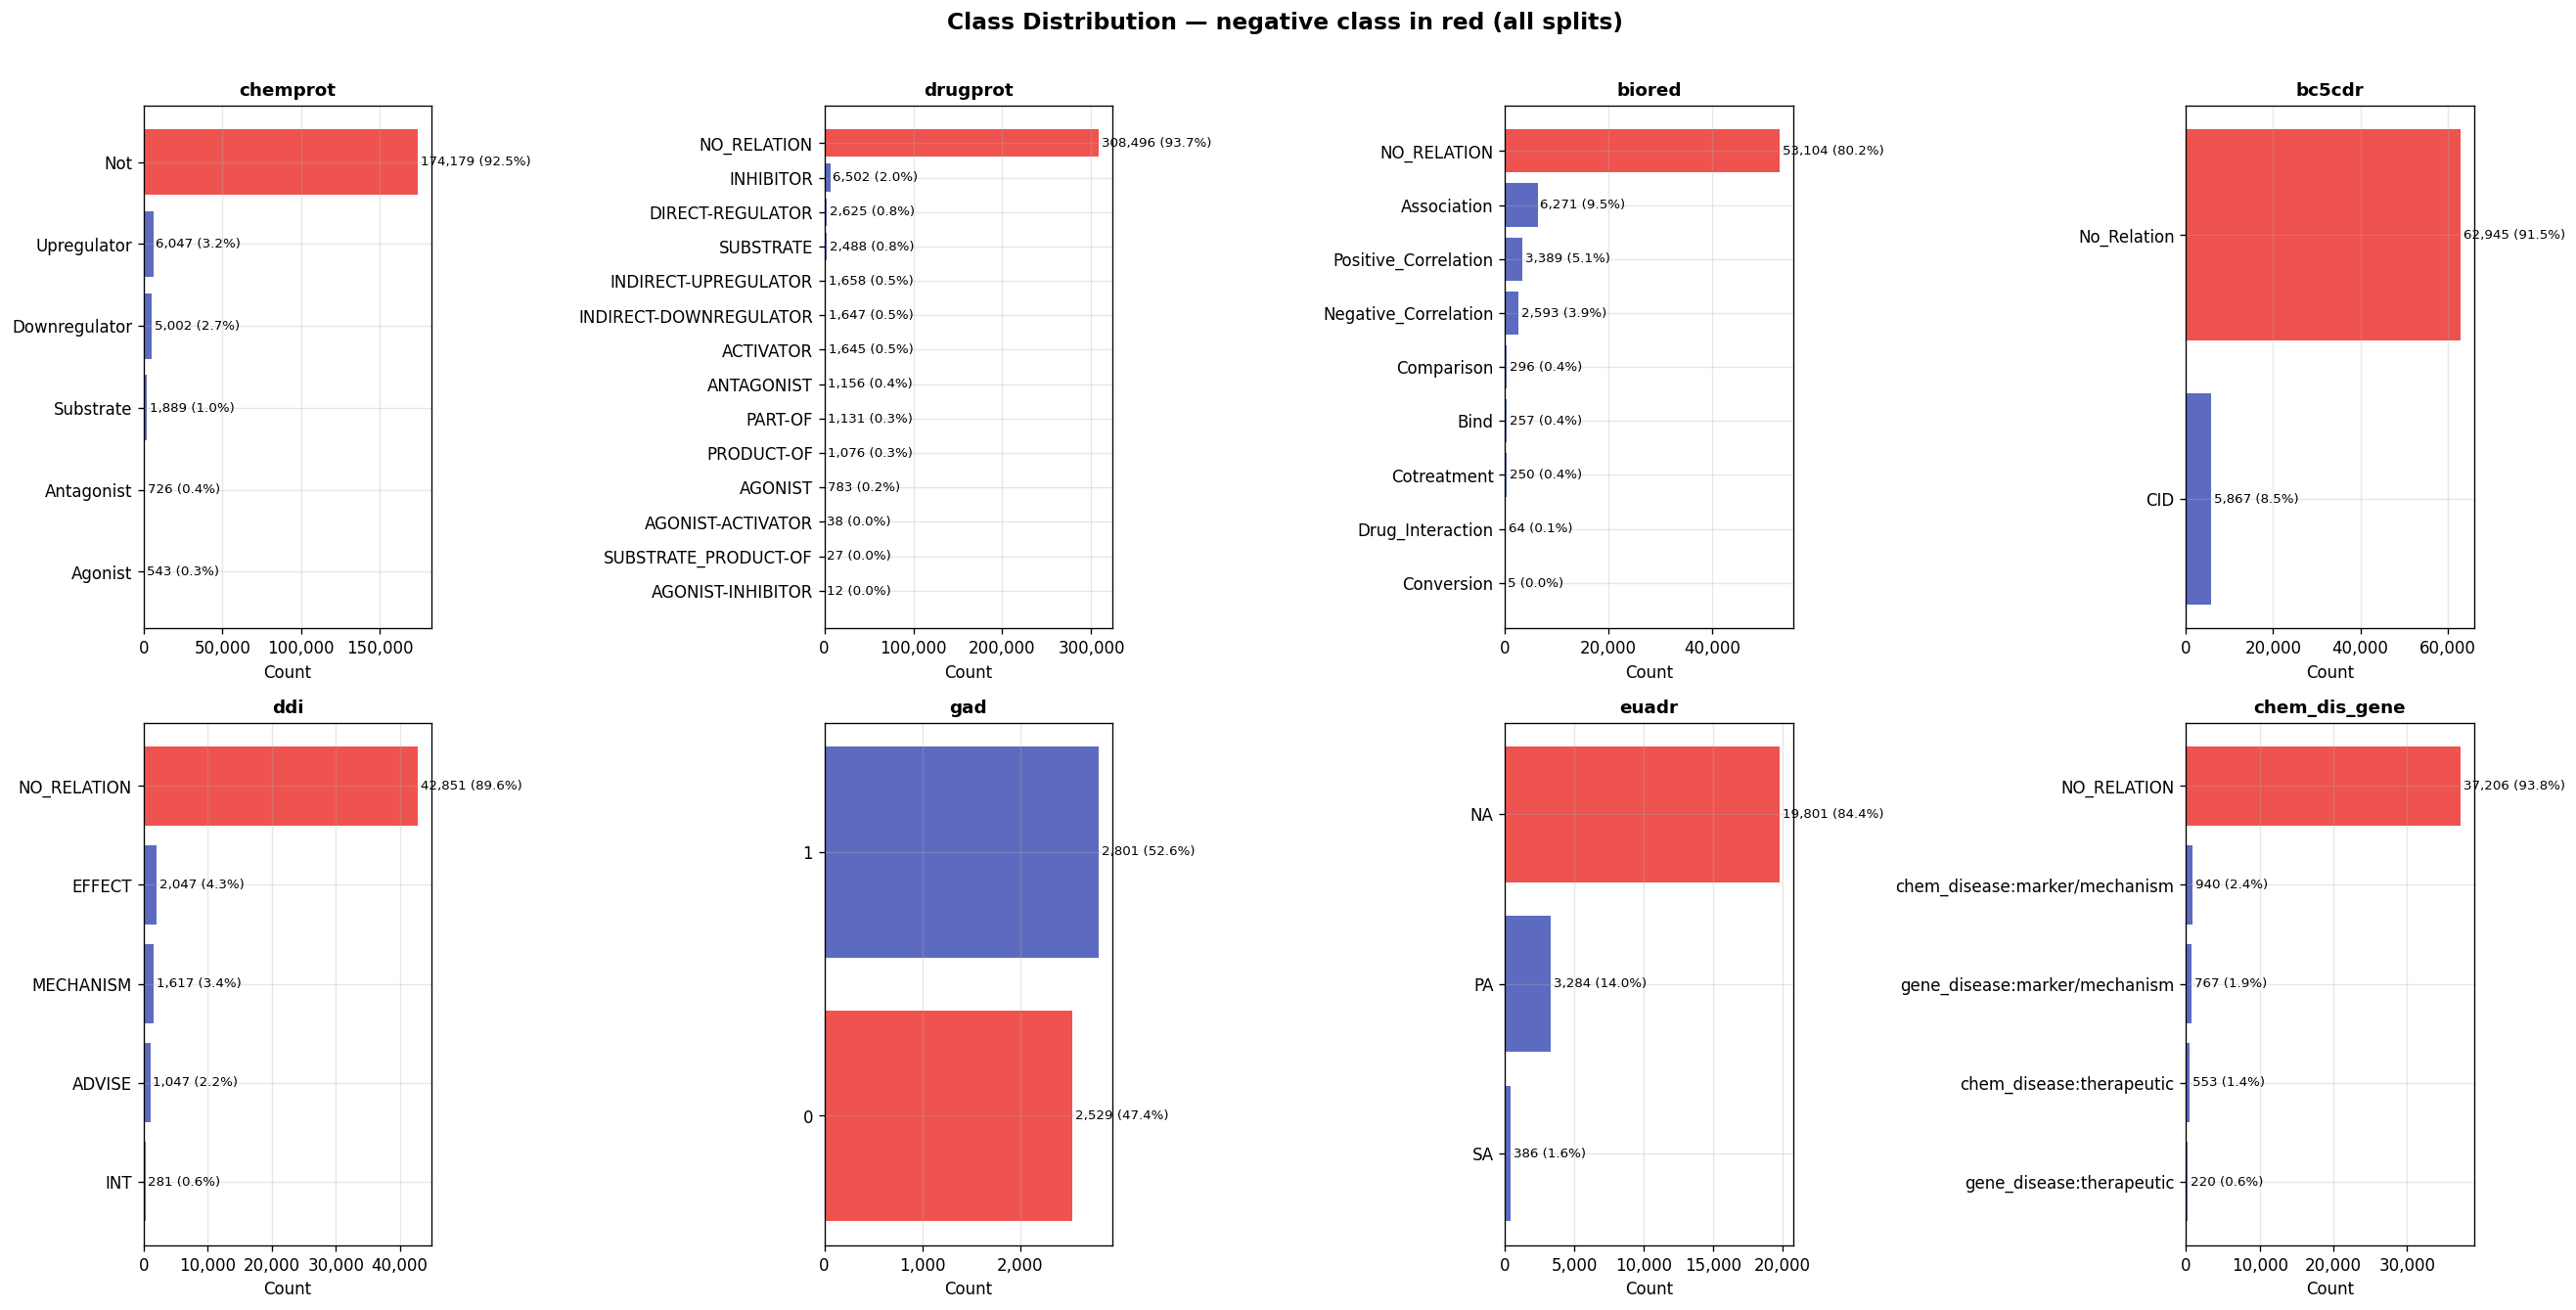

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(22, 11))
axes = axes.flatten()

for idx, ds_name in enumerate(DATASET_NAMES):
    ax = axes[idx]
    info = all_data[ds_name]

    all_labels = []
    for split_name in ["train", "validation", "test"]:
        examples = info["splits"][split_name]
        if examples:
            all_labels.extend([ex.label for ex in examples])

    label_counts = Counter(all_labels)
    labels_sorted = sorted(label_counts.keys(), key=lambda l: label_counts[l], reverse=True)
    counts_sorted = [label_counts[l] for l in labels_sorted]

    neg_label = NEGATIVE_LABELS.get(ds_name)
    colors = ["#EF5350" if l == neg_label else "#5C6BC0" for l in labels_sorted]

    bars = ax.barh(labels_sorted, counts_sorted, color=colors)
    ax.invert_yaxis()
    ax.set_title(ds_name, fontsize=11, fontweight="bold")
    ax.set_xlabel("Count")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))

    total = sum(counts_sorted)
    for bar, count in zip(bars, counts_sorted):
        ax.text(bar.get_width() + max(counts_sorted) * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{count:,} ({count/total*100:.1f}%)",
                va="center", fontsize=8)

for idx in range(len(DATASET_NAMES), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("Class Distribution — negative class in red (all splits)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [10]:
balance_rows = []
for ds_name in DATASET_NAMES:
    info = all_data[ds_name]
    neg_label = NEGATIVE_LABELS.get(ds_name)
    for split_name in ["train", "validation", "test"]:
        examples = info["splits"][split_name]
        if not examples:
            continue
        n_pos = sum(1 for ex in examples if ex.label != neg_label)
        n_neg = sum(1 for ex in examples if ex.label == neg_label)
        total = n_pos + n_neg
        balance_rows.append({
            "Dataset": ds_name,
            "Split": split_name,
            "Positive": n_pos,
            "Negative": n_neg,
            "Total": total,
            "Pos %": f"{n_pos/total*100:.1f}%" if total else "-",
            "Imbalance (neg:pos)": f"{n_neg/max(n_pos,1):.1f}",
        })

pd.DataFrame(balance_rows)

,Dataset,Split,Positive,Negative,Total,Pos %,Imbalance (neg:pos)
0,chemprot,train,5836,71416,77252,7.6%,12.2
1,chemprot,validation,3185,43317,46502,6.8%,13.6
2,chemprot,test,5186,59446,64632,8.0%,11.5
3,drugprot,train,17057,255861,272918,6.2%,15.0
4,drugprot,validation,3731,52635,56366,6.6%,14.1
5,biored,train,8774,34264,43038,20.4%,3.9
6,biored,validation,2266,9301,11567,19.6%,4.1
7,biored,test,2085,9539,11624,17.9%,4.6
8,bc5cdr,train,1902,20494,22396,8.5%,10.8
9,bc5cdr,validation,2034,21280,23314,8.7%,10.5


### Per-split class distribution

The cell above shows positives vs negatives per split. The table and plot below break out **every class** per split so we can see whether the train/val/test splits share the same class profile (or whether one class is over-represented in eval).


In [11]:
# Per-(dataset, split, class) counts — long-form table
rows = []
for ds_name in DATASET_NAMES:
    info = all_data[ds_name]
    for split_name in ["train", "validation", "test"]:
        examples = info["splits"][split_name]
        if not examples:
            continue
        total = len(examples)
        c = Counter(ex.label for ex in examples)
        for label, count in c.most_common():
            rows.append({
                "Dataset": ds_name,
                "Split": split_name,
                "Label": label,
                "Count": count,
                "Pct": f"{count/total*100:.1f}%",
            })

per_split_class_df = pd.DataFrame(rows)
per_split_class_df


,Dataset,Split,Label,Count,Pct
0,chemprot,train,Not,71416,92.4%
1,chemprot,train,Upregulator,2391,3.1%
2,chemprot,train,Downregulator,2251,2.9%
3,chemprot,train,Substrate,761,1.0%
4,chemprot,train,Antagonist,234,0.3%
...,...,...,...,...,...
117,chem_dis_gene,test,NO_RELATION,5554,93.3%
118,chem_dis_gene,test,chem_disease:marker/mechanism,155,2.6%
119,chem_dis_gene,test,gene_disease:marker/mechanism,122,2.0%
120,chem_dis_gene,test,chem_disease:therapeutic,84,1.4%


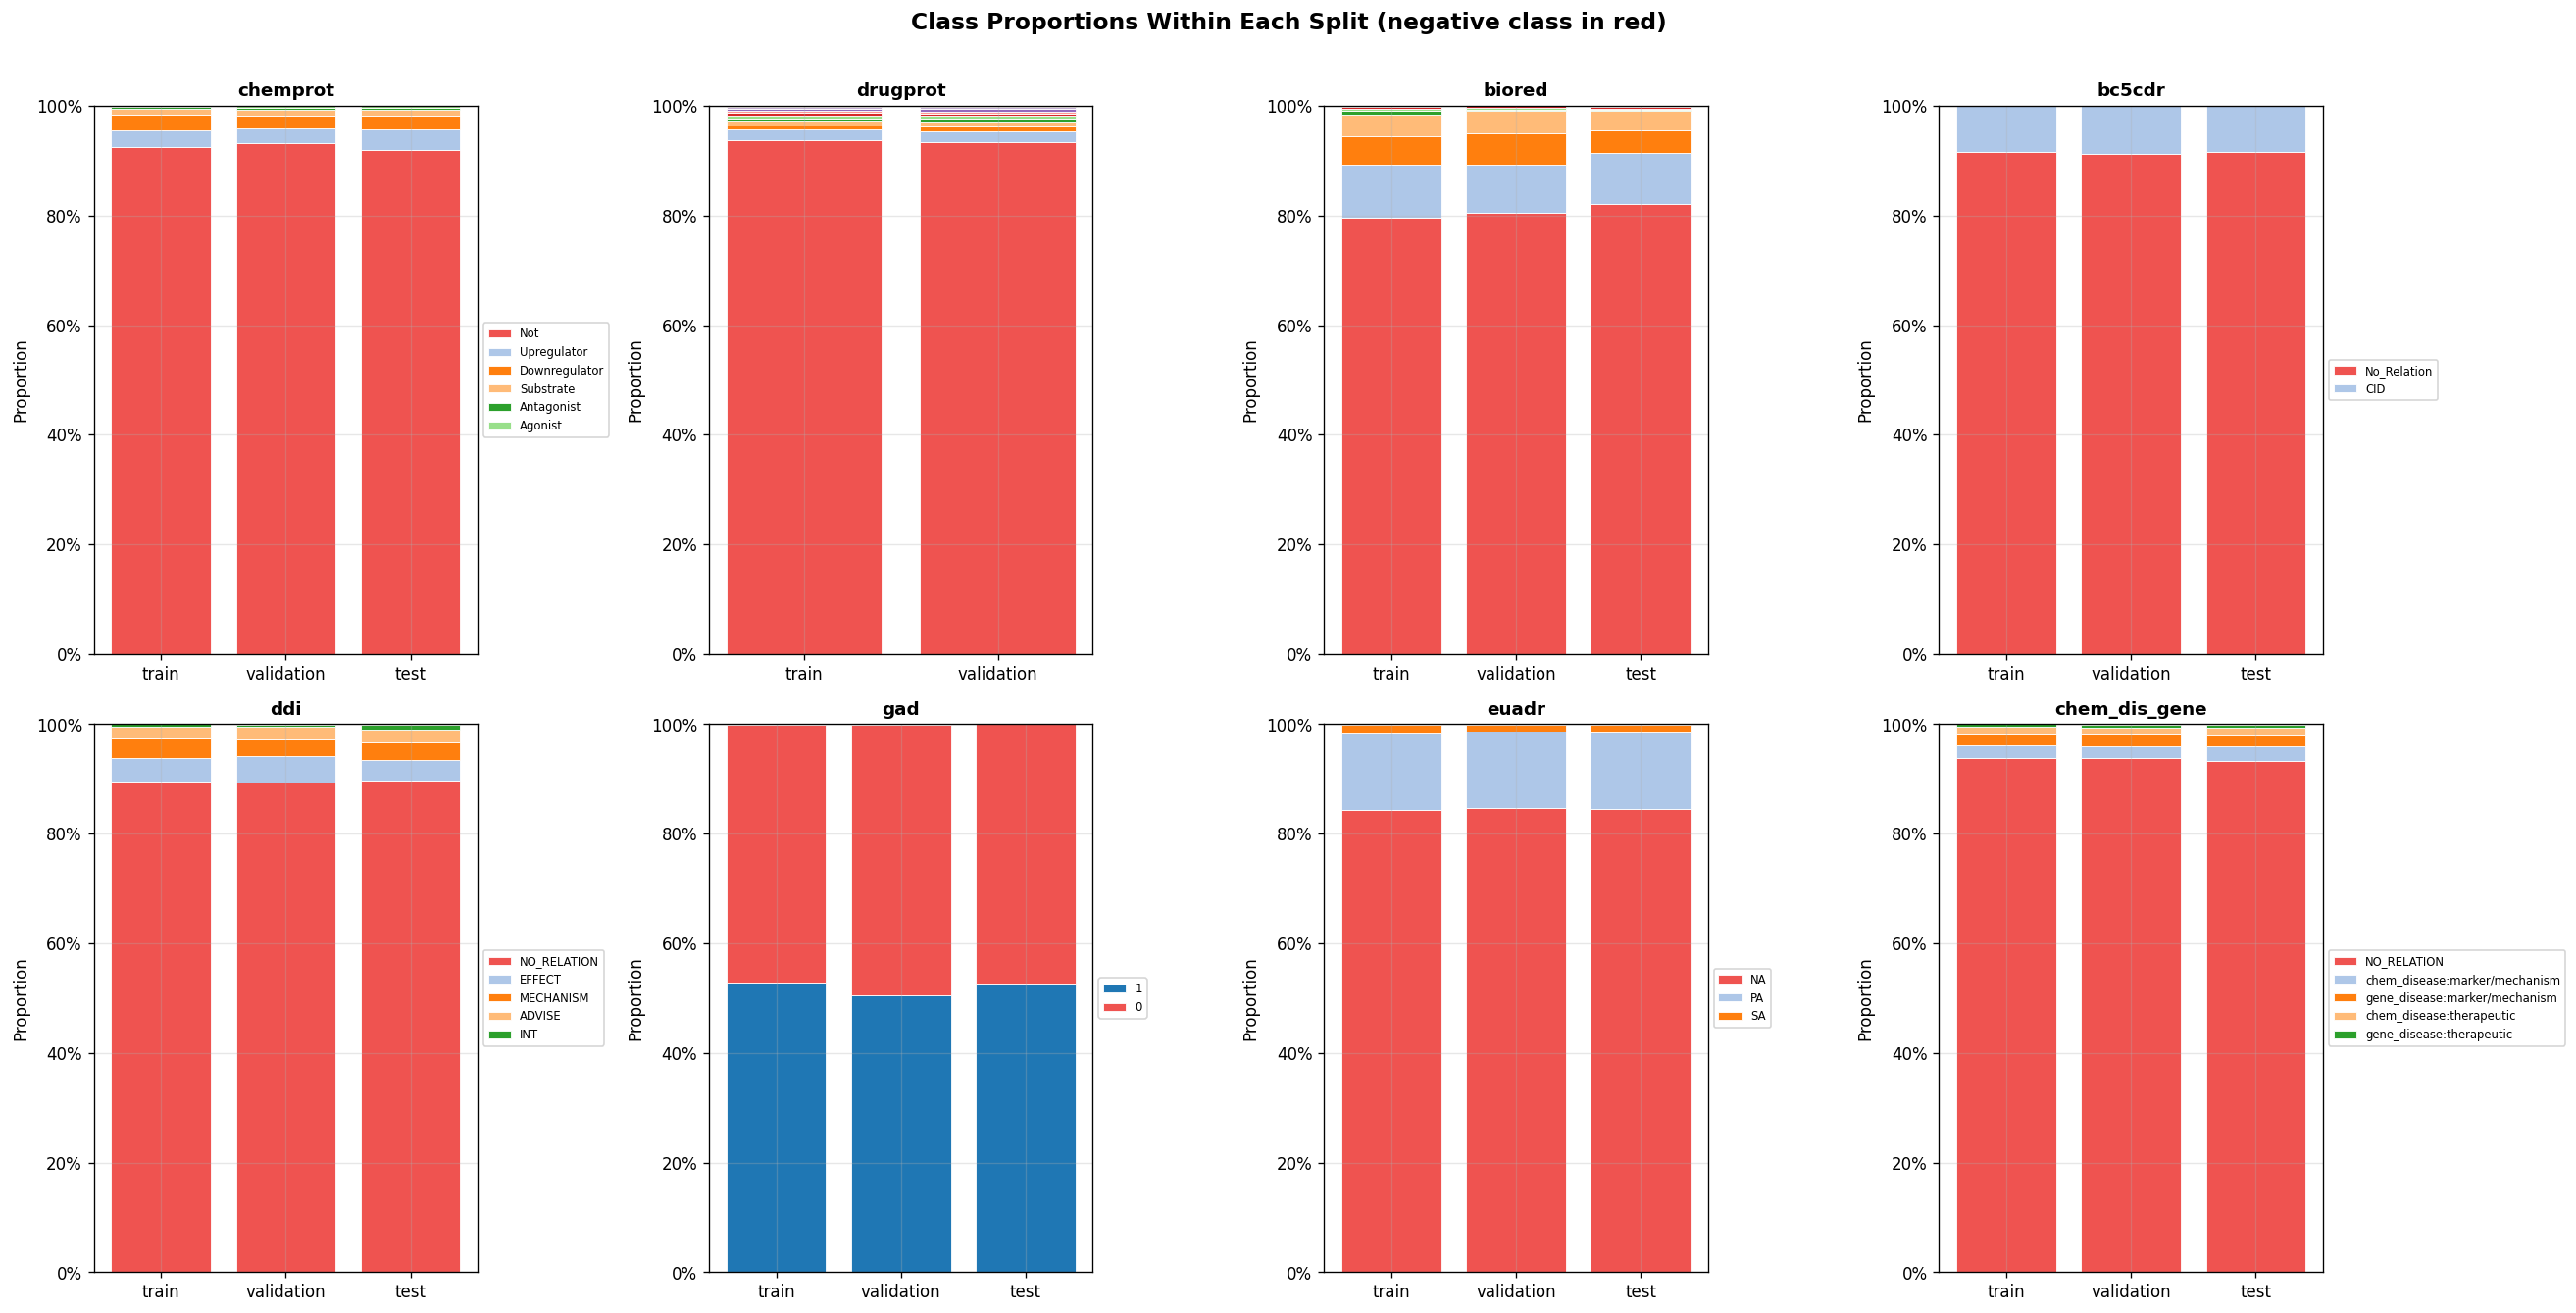

In [12]:
# Stacked bars: class proportions within each split per dataset
fig, axes = plt.subplots(2, 4, figsize=(22, 11))
axes = axes.flatten()

for idx, ds_name in enumerate(DATASET_NAMES):
    ax = axes[idx]
    info = all_data[ds_name]

    # Collect class counts per split
    split_class_counts = {}
    for split_name in ["train", "validation", "test"]:
        examples = info["splits"][split_name]
        if not examples:
            continue
        split_class_counts[split_name] = Counter(ex.label for ex in examples)

    if not split_class_counts:
        ax.set_visible(False)
        continue

    # Union of labels, ordered by total frequency
    all_labels = sorted(
        {l for c in split_class_counts.values() for l in c},
        key=lambda l: -sum(c.get(l, 0) for c in split_class_counts.values()),
    )
    splits = list(split_class_counts.keys())
    neg_label = NEGATIVE_LABELS.get(ds_name)

    # Build stacked proportions
    bottoms = np.zeros(len(splits))
    cmap = plt.get_cmap("tab20")
    for li, lab in enumerate(all_labels):
        vals = np.array([
            split_class_counts[s].get(lab, 0) / max(sum(split_class_counts[s].values()), 1)
            for s in splits
        ])
        color = "#EF5350" if lab == neg_label else cmap(li % 20)
        ax.bar(splits, vals, bottom=bottoms, color=color,
               label=lab if li < 8 else None, edgecolor="white", linewidth=0.5)
        bottoms += vals

    ax.set_ylim(0, 1)
    ax.set_title(ds_name, fontsize=11, fontweight="bold")
    ax.set_ylabel("Proportion")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0%}"))
    if len(all_labels) <= 8:
        ax.legend(fontsize=7, loc="center left", bbox_to_anchor=(1.0, 0.5))

for idx in range(len(DATASET_NAMES), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("Class Proportions Within Each Split (negative class in red)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


## 6. Resampling: ROS, Tomek, and Tomek + ROS Hybrid

Compares train-split distribution at 4 stages:
- **Original** — natural imbalance
- **ROS only** — random oversampling, all classes upsampled to majority size
- **Tomek only** — Tomek Links boundary cleaning (removes ambiguous majority samples)
- **Tomek + ROS** — hybrid: clean first, then balance

**Heads-up:** Tomek requires embedding every train pair with `sentence-transformers/all-MiniLM-L6-v2`. First-run cost ~30 min total on CPU across all 8 datasets, ~2 min on GPU. Embeddings are cached — set `RUN_TOMEK = False` to skip if you don't want to wait.

In [13]:
# Toggle this off if you want to skip the (potentially slow) Tomek step
import numpy as np
RUN_TOMEK = True

# Cache directory for embeddings — reused on subsequent runs
TOMEK_CACHE_DIR = "./_tomek_cache"

tomek_results = {}

# tomek_results['chemprot'] = np.load('_tomek_cache/chemprot_train__sentence-transformers_all-MiniLM-L6-v2.npz')
# tomek_results['drugprot'] = np.load('_tomek_cache/drugprot_train__sentence-transformers_all-MiniLM-L6-v2.npz')
# tomek_results['biored'] = np.load('_tomek_cache/biored_train__sentence-transformers_all-MiniLM-L6-v2.npz')
# tomek_results['bc5cdr'] = np.load('_tomek_cache/bc5cdr_train__sentence-transformers_all-MiniLM-L6-v2.npz')
# tomek_results['ddi'] = np.load('_tomek_cache/ddi_train__sentence-transformers_all-MiniLM-L6-v2.npz')
# tomek_results['gad'] = np.load('_tomek_cache/gad_train__sentence-transformers_all-MiniLM-L6-v2.npz')
# tomek_results['euadr'] = np.load('_tomek_cache/euadr_train__sentence-transformers_all-MiniLM-L6-v2.npz')
# tomek_results['chem_dis_gene'] = np.load('_tomek_cache/chem_dis_gene_train__sentence-transformers_all-MiniLM-L6-v2.npz')
# print(type(tomek_results.get('ddi')))

if RUN_TOMEK:
    for ds_name in DATASET_NAMES:
        examples = all_data[ds_name]["splits"]["train"]
        if not examples:
            continue
        print(f"\n--- {ds_name} ({len(examples):,} train pairs) ---")
        cleaned = clean_with_tomek(
            examples,
            entity_marker_strategy="typed_entity_marker_punct",
            cache_dir=TOMEK_CACHE_DIR,
            cache_key=f"{ds_name}_train",
        )
        tomek_results[ds_name] = cleaned
    print("\nTomek complete for all datasets.")
else:
    print("Tomek step skipped (RUN_TOMEK=False)")


--- chemprot (77,252 train pairs) ---


Batches:   0%|          | 0/604 [00:00<?, ?it/s]


--- drugprot (272,918 train pairs) ---


Batches:   0%|          | 0/2133 [00:00<?, ?it/s]


--- biored (43,038 train pairs) ---


...


--- gad (4,077 train pairs) ---

--- euadr (16,431 train pairs) ---


Batches:   0%|          | 0/129 [00:00<?, ?it/s]


--- chem_dis_gene (27,782 train pairs) ---


Batches:   0%|          | 0/218 [00:00<?, ?it/s]


Tomek complete for all datasets.


In [14]:
# Build the 4-stage summary table
stage_rows = []
for ds_name in DATASET_NAMES:
    examples = all_data[ds_name]["splits"]["train"]
    if not examples:
        continue

    ros_only = random_oversample(examples, seed=42)
    tomek_only = tomek_results.get(ds_name)
    tomek_ros = random_oversample(tomek_only, seed=42) if tomek_only is not None else None

    neg_label = NEGATIVE_LABELS.get(ds_name)

    def imbalance(exs):
        if exs is None:
            return None
        c = Counter(ex.label for ex in exs)
        n_pos = sum(v for k, v in c.items() if k != neg_label)
        n_neg = c.get(neg_label, 0)
        return n_neg / max(n_pos, 1)

    stage_rows.append({
        "Dataset": ds_name,
        "Original": f"{len(examples):,}",
        "ROS only": f"{len(ros_only):,}",
        "Tomek only": f"{len(tomek_only):,}" if tomek_only is not None else "-",
        "Tomek+ROS": f"{len(tomek_ros):,}" if tomek_ros is not None else "-",
        "Imb. Original": f"{imbalance(examples):.2f}",
        "Imb. ROS": f"{imbalance(ros_only):.2f}",
        "Imb. Tomek": f"{imbalance(tomek_only):.2f}" if tomek_only is not None else "-",
        "Imb. T+ROS": f"{imbalance(tomek_ros):.2f}" if tomek_ros is not None else "-",
        "Tomek removed %": (
            f"{(len(examples)-len(tomek_only))/len(examples)*100:.1f}%"
            if tomek_only is not None else "-"
        ),
    })

pd.DataFrame(stage_rows)

,Dataset,Original,ROS only,Tomek only,Tomek+ROS,Imb. Original,Imb. ROS,Imb. Tomek,Imb. T+ROS,Tomek removed %
0,chemprot,"77,252","428,496","72,699","401,244",12.24,0.20,11.48,0.20,5.9%
1,drugprot,"272,918","3,582,054","259,802","3,399,186",15.00,0.08,14.28,0.08,4.8%
2,biored,"43,038","308,376","36,340","248,391",3.91,0.12,3.16,0.12,15.6%
3,bc5cdr,"22,396","40,988","20,881","37,958",10.77,1.00,9.98,1.00,6.8%
4,ddi,"32,512","145,535","30,641","136,185",8.55,0.25,8.00,0.25,5.8%
5,gad,"4,077","4,314","3,745","3,840",0.89,1.00,1.05,1.00,8.1%
6,euadr,"16,431","41,541","14,913","37,062",5.36,0.50,4.83,0.50,9.2%
7,chem_dis_gene,"27,782","130,340","26,704","124,995",15.21,0.25,14.66,0.25,3.9%


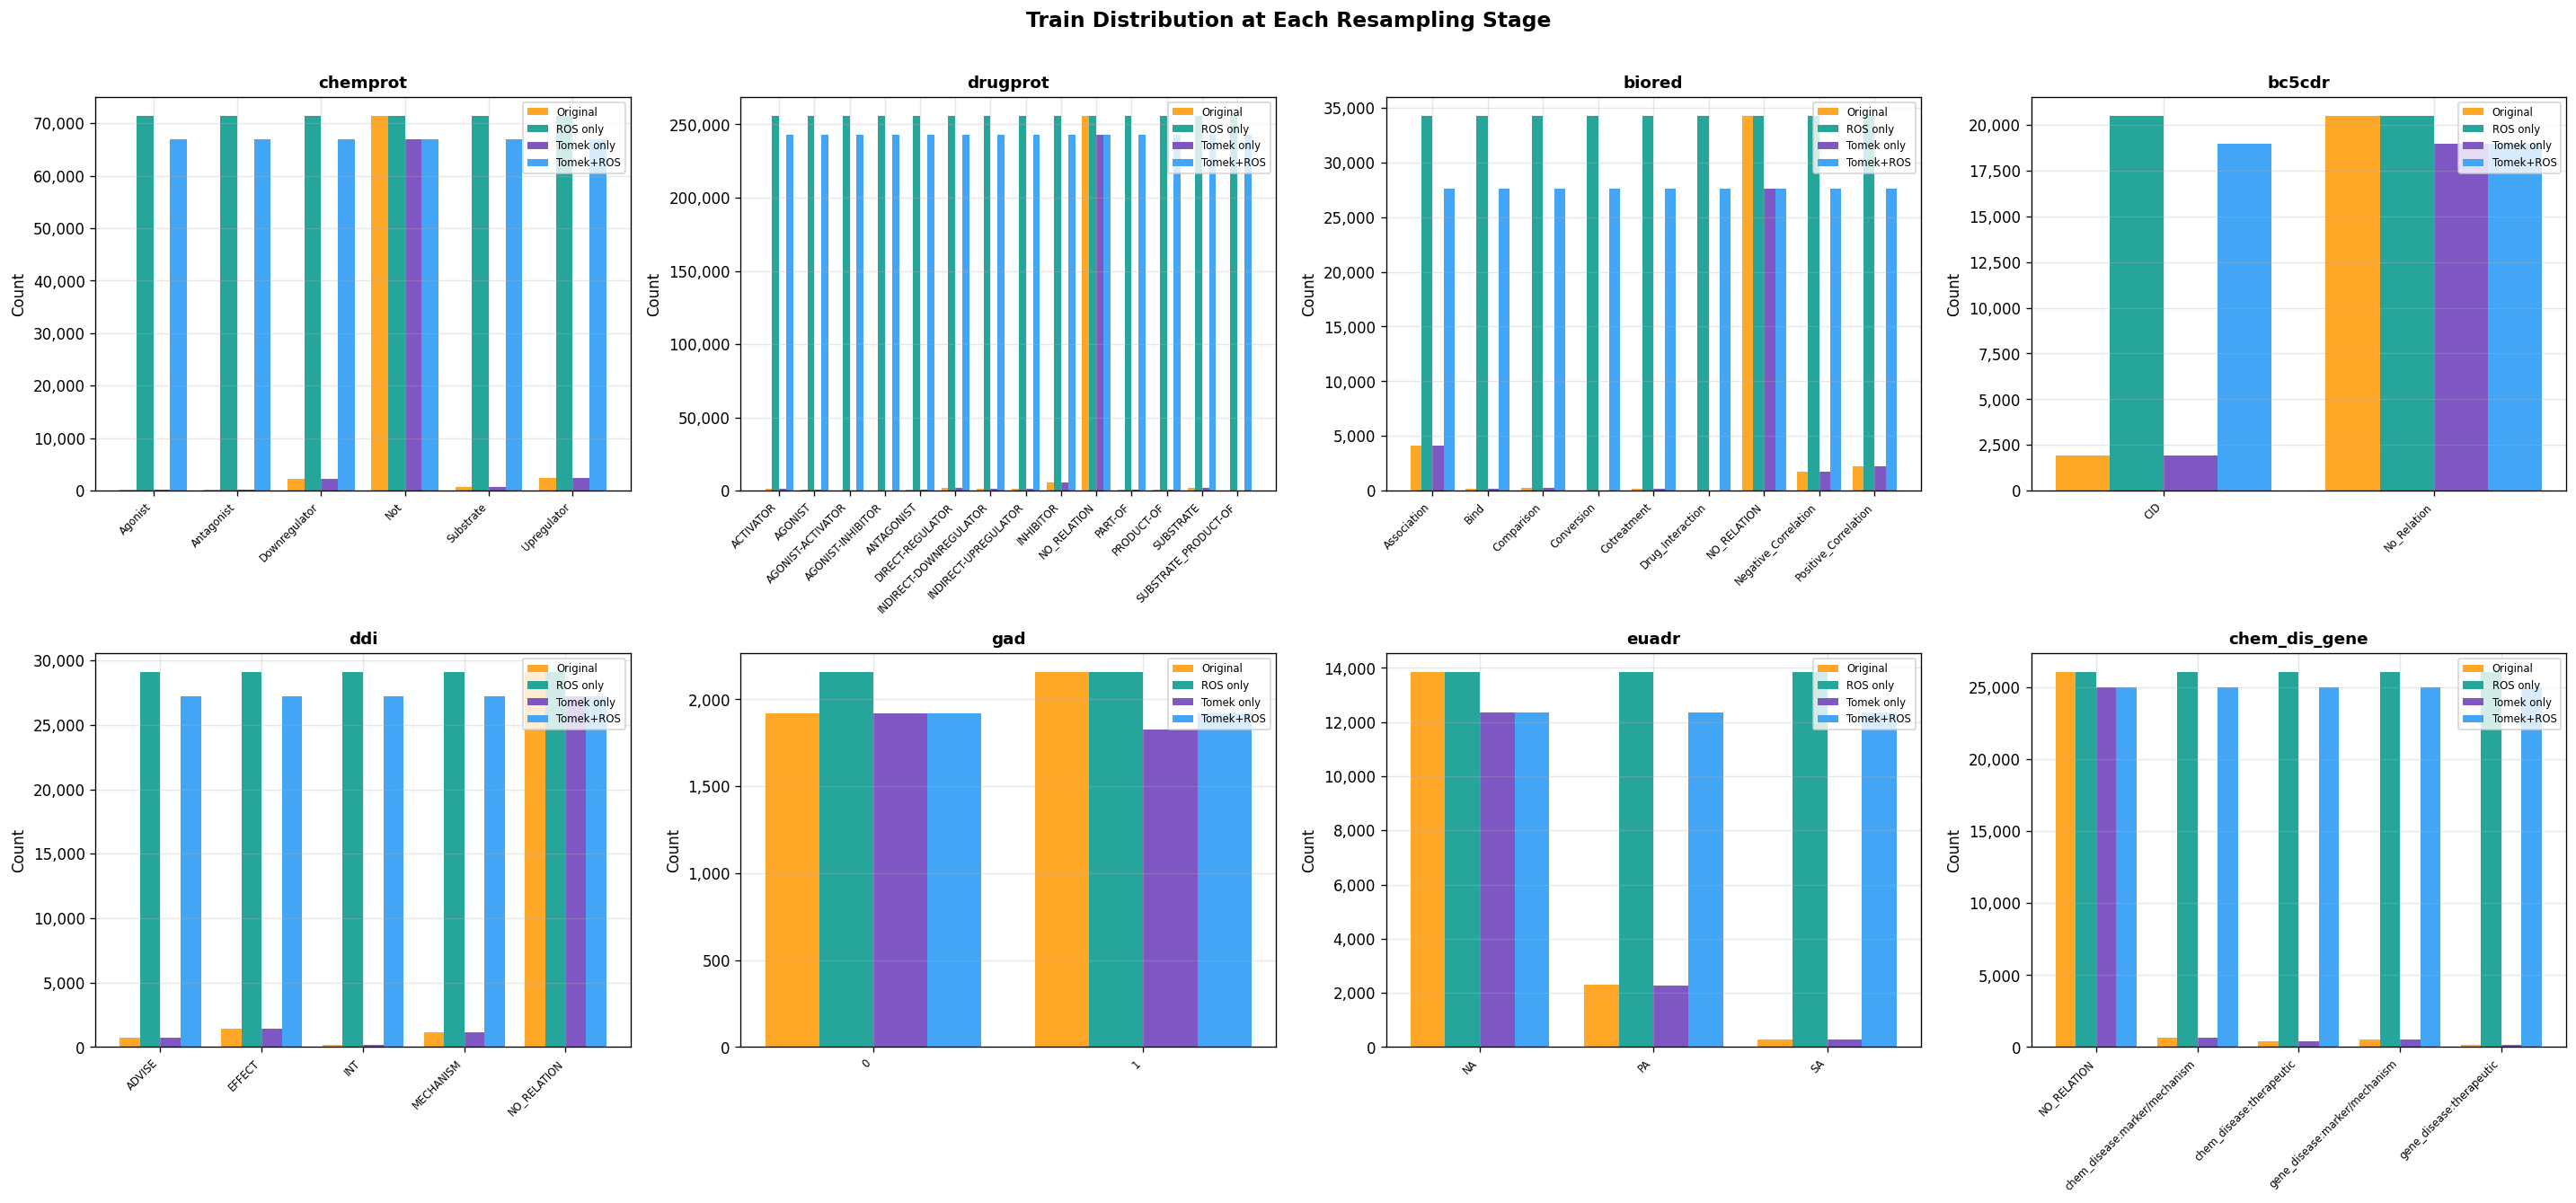

In [15]:
# Per-dataset 4-bar plot: count of each label at each stage
fig, axes = plt.subplots(2, 4, figsize=(24, 11))
axes = axes.flatten()

stage_colors = {
    "Original":   "#FFA726",
    "ROS only":   "#26A69A",
    "Tomek only": "#7E57C2",
    "Tomek+ROS":  "#42A5F5",
}

for idx, ds_name in enumerate(DATASET_NAMES):
    ax = axes[idx]
    examples = all_data[ds_name]["splits"]["train"]
    if not examples:
        ax.set_visible(False)
        continue

    ros_only = random_oversample(examples, seed=42)
    tomek_only = tomek_results.get(ds_name)
    tomek_ros = random_oversample(tomek_only, seed=42) if tomek_only is not None else None

    stages = {"Original": examples, "ROS only": ros_only}
    if tomek_only is not None:
        stages["Tomek only"] = tomek_only
        stages["Tomek+ROS"] = tomek_ros

    all_labels = sorted({l for exs in stages.values() for l in {ex.label for ex in exs}})
    n_stages = len(stages)
    bar_w = 0.8 / n_stages
    x = np.arange(len(all_labels))

    for s_idx, (stage_name, exs) in enumerate(stages.items()):
        c = Counter(ex.label for ex in exs)
        counts = [c.get(l, 0) for l in all_labels]
        offset = (s_idx - (n_stages - 1) / 2) * bar_w
        ax.bar(x + offset, counts, bar_w, label=stage_name, color=stage_colors[stage_name])

    ax.set_xticks(x)
    ax.set_xticklabels(all_labels, rotation=45, ha="right", fontsize=7)
    ax.set_title(ds_name, fontsize=11, fontweight="bold")
    ax.set_ylabel("Count")
    ax.legend(fontsize=7, loc="upper right")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))

for idx in range(len(DATASET_NAMES), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("Train Distribution at Each Resampling Stage", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

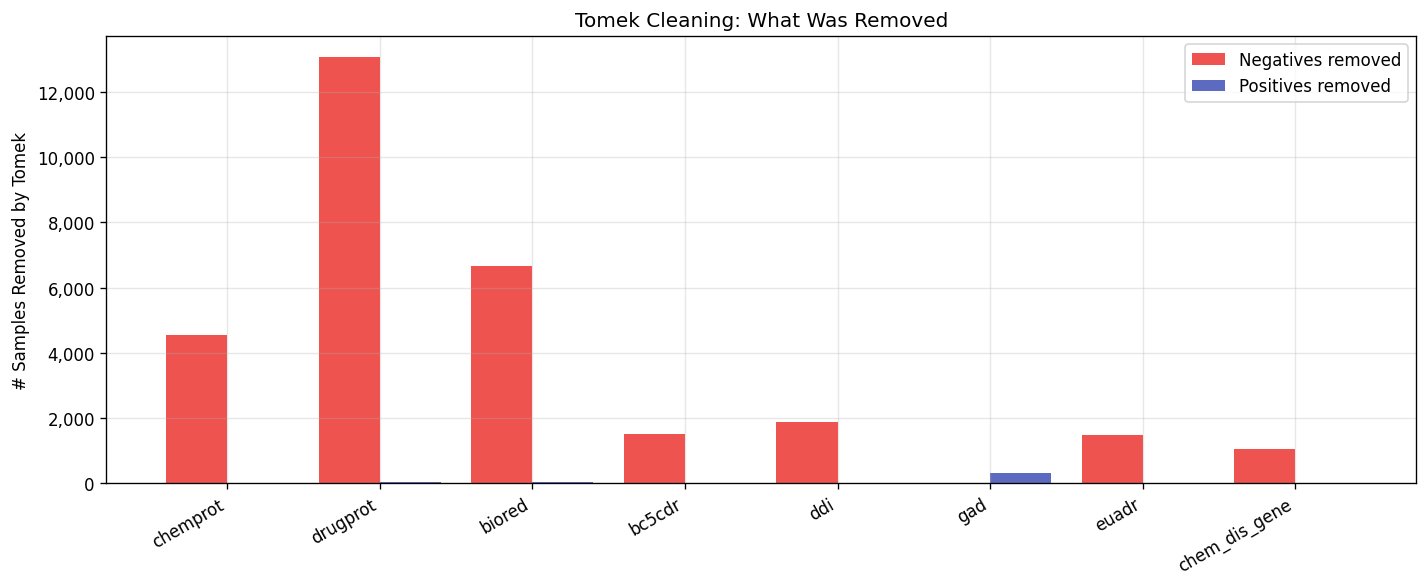

In [16]:
# Just show what Tomek removed vs kept (positives/negatives) per dataset
if tomek_results:
    fig, ax = plt.subplots(figsize=(12, 5))
    ds_with_tomek = list(tomek_results.keys())
    x = np.arange(len(ds_with_tomek))
    w = 0.4

    removed_neg = []
    removed_pos = []
    for ds_name in ds_with_tomek:
        original = all_data[ds_name]["splits"]["train"]
        cleaned = tomek_results[ds_name]
        neg_label = NEGATIVE_LABELS.get(ds_name)
        c_orig_neg = sum(1 for ex in original if ex.label == neg_label)
        c_orig_pos = sum(1 for ex in original if ex.label != neg_label)
        c_clean_neg = sum(1 for ex in cleaned if ex.label == neg_label)
        c_clean_pos = sum(1 for ex in cleaned if ex.label != neg_label)
        removed_neg.append(c_orig_neg - c_clean_neg)
        removed_pos.append(c_orig_pos - c_clean_pos)

    ax.bar(x - w/2, removed_neg, w, label="Negatives removed", color="#EF5350")
    ax.bar(x + w/2, removed_pos, w, label="Positives removed", color="#5C6BC0")
    ax.set_xticks(x)
    ax.set_xticklabels(ds_with_tomek, rotation=30, ha="right")
    ax.set_ylabel("# Samples Removed by Tomek")
    ax.set_title("Tomek Cleaning: What Was Removed")
    ax.legend()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
    plt.tight_layout()
    plt.show()

## 7. Binary-Mode Resampling: ROS, Tomek, and Tomek+ROS

Same 4-stage comparison as section 6, but with labels collapsed to binary first (`label_id == 0` → 0 no-relation, everything else → 1 relation). This is the binary classification paradigm: the model learns *whether* a relation exists, regardless of type. Tomek pairs are recomputed on the binary labels, so a positive-of-type-A near a positive-of-type-B is **not** a Tomek link in binary mode (whereas in multi-class it would be).

Embeddings are re-used from section 6 — `clean_with_tomek` caches by text hash, not labels, so the only re-computation is the nearest-neighbor lookup over the binary labels.


In [17]:
# Run Tomek on the binary-collapsed train splits
from medre_bench.datasets.preprocessing import collapse_to_binary

binary_train = {ds: collapse_to_binary(all_data[ds]["splits"]["train"])
                for ds in DATASET_NAMES if all_data[ds]["splits"]["train"]}

binary_tomek_results = {}
if RUN_TOMEK:
    for ds_name, examples in binary_train.items():
        print(f"\n--- {ds_name} (binary, {len(examples):,} train pairs) ---")
        cleaned = clean_with_tomek(
            examples,
            entity_marker_strategy="typed_entity_marker_punct",
            cache_dir=TOMEK_CACHE_DIR,
            cache_key=f"{ds_name}_train",  # same key → re-use cached embeddings
        )
        binary_tomek_results[ds_name] = cleaned
    print("\nBinary Tomek complete.")
else:
    print("Tomek step skipped (RUN_TOMEK=False)")



--- chemprot (binary, 77,252 train pairs) ---

--- drugprot (binary, 272,918 train pairs) ---

--- biored (binary, 43,038 train pairs) ---

--- bc5cdr (binary, 22,396 train pairs) ---

--- ddi (binary, 32,512 train pairs) ---

--- gad (binary, 4,077 train pairs) ---

--- euadr (binary, 16,431 train pairs) ---

--- chem_dis_gene (binary, 27,782 train pairs) ---

Binary Tomek complete.


In [18]:
# 4-stage summary table — binary labels
BINARY_NEG = "NO_RELATION"  # from collapse_to_binary

binary_stage_rows = []
for ds_name in DATASET_NAMES:
    examples = binary_train.get(ds_name)
    if not examples:
        continue

    ros_only = random_oversample(examples, seed=42)
    tomek_only = binary_tomek_results.get(ds_name)
    tomek_ros = random_oversample(tomek_only, seed=42) if tomek_only is not None else None

    def imb(exs):
        if exs is None:
            return None
        c = Counter(ex.label for ex in exs)
        n_pos = c.get("RELATION", 0)
        n_neg = c.get(BINARY_NEG, 0)
        return n_neg / max(n_pos, 1)

    binary_stage_rows.append({
        "Dataset": ds_name,
        "Original": f"{len(examples):,}",
        "ROS only": f"{len(ros_only):,}",
        "Tomek only": f"{len(tomek_only):,}" if tomek_only is not None else "-",
        "Tomek+ROS": f"{len(tomek_ros):,}" if tomek_ros is not None else "-",
        "Imb. Original": f"{imb(examples):.2f}",
        "Imb. ROS": f"{imb(ros_only):.2f}",
        "Imb. Tomek": f"{imb(tomek_only):.2f}" if tomek_only is not None else "-",
        "Imb. T+ROS": f"{imb(tomek_ros):.2f}" if tomek_ros is not None else "-",
        "Tomek removed %": (
            f"{(len(examples)-len(tomek_only))/len(examples)*100:.1f}%"
            if tomek_only is not None else "-"
        ),
    })

pd.DataFrame(binary_stage_rows)


,Dataset,Original,ROS only,Tomek only,Tomek+ROS,Imb. Original,Imb. ROS,Imb. Tomek,Imb. T+ROS,Tomek removed %
0,chemprot,"77,252","142,832","72,710","133,748",12.24,1.00,11.46,1.00,5.9%
1,drugprot,"272,918","511,722","259,856","485,598",15.00,1.00,14.23,1.00,4.8%
2,biored,"43,038","68,528","36,373","55,198",3.91,1.00,3.15,1.00,15.5%
3,bc5cdr,"22,396","40,988","20,881","37,958",10.77,1.00,9.98,1.00,6.8%
4,ddi,"32,512","58,214","30,642","54,474",8.55,1.00,8.00,1.00,5.8%
5,gad,"4,077","4,314","3,745","3,840",0.89,1.00,1.05,1.00,8.1%
6,euadr,"16,431","27,694","14,938","24,708",5.36,1.00,4.78,1.00,9.1%
7,chem_dis_gene,"27,782","52,136","26,713","49,998",15.21,1.00,14.59,1.00,3.8%


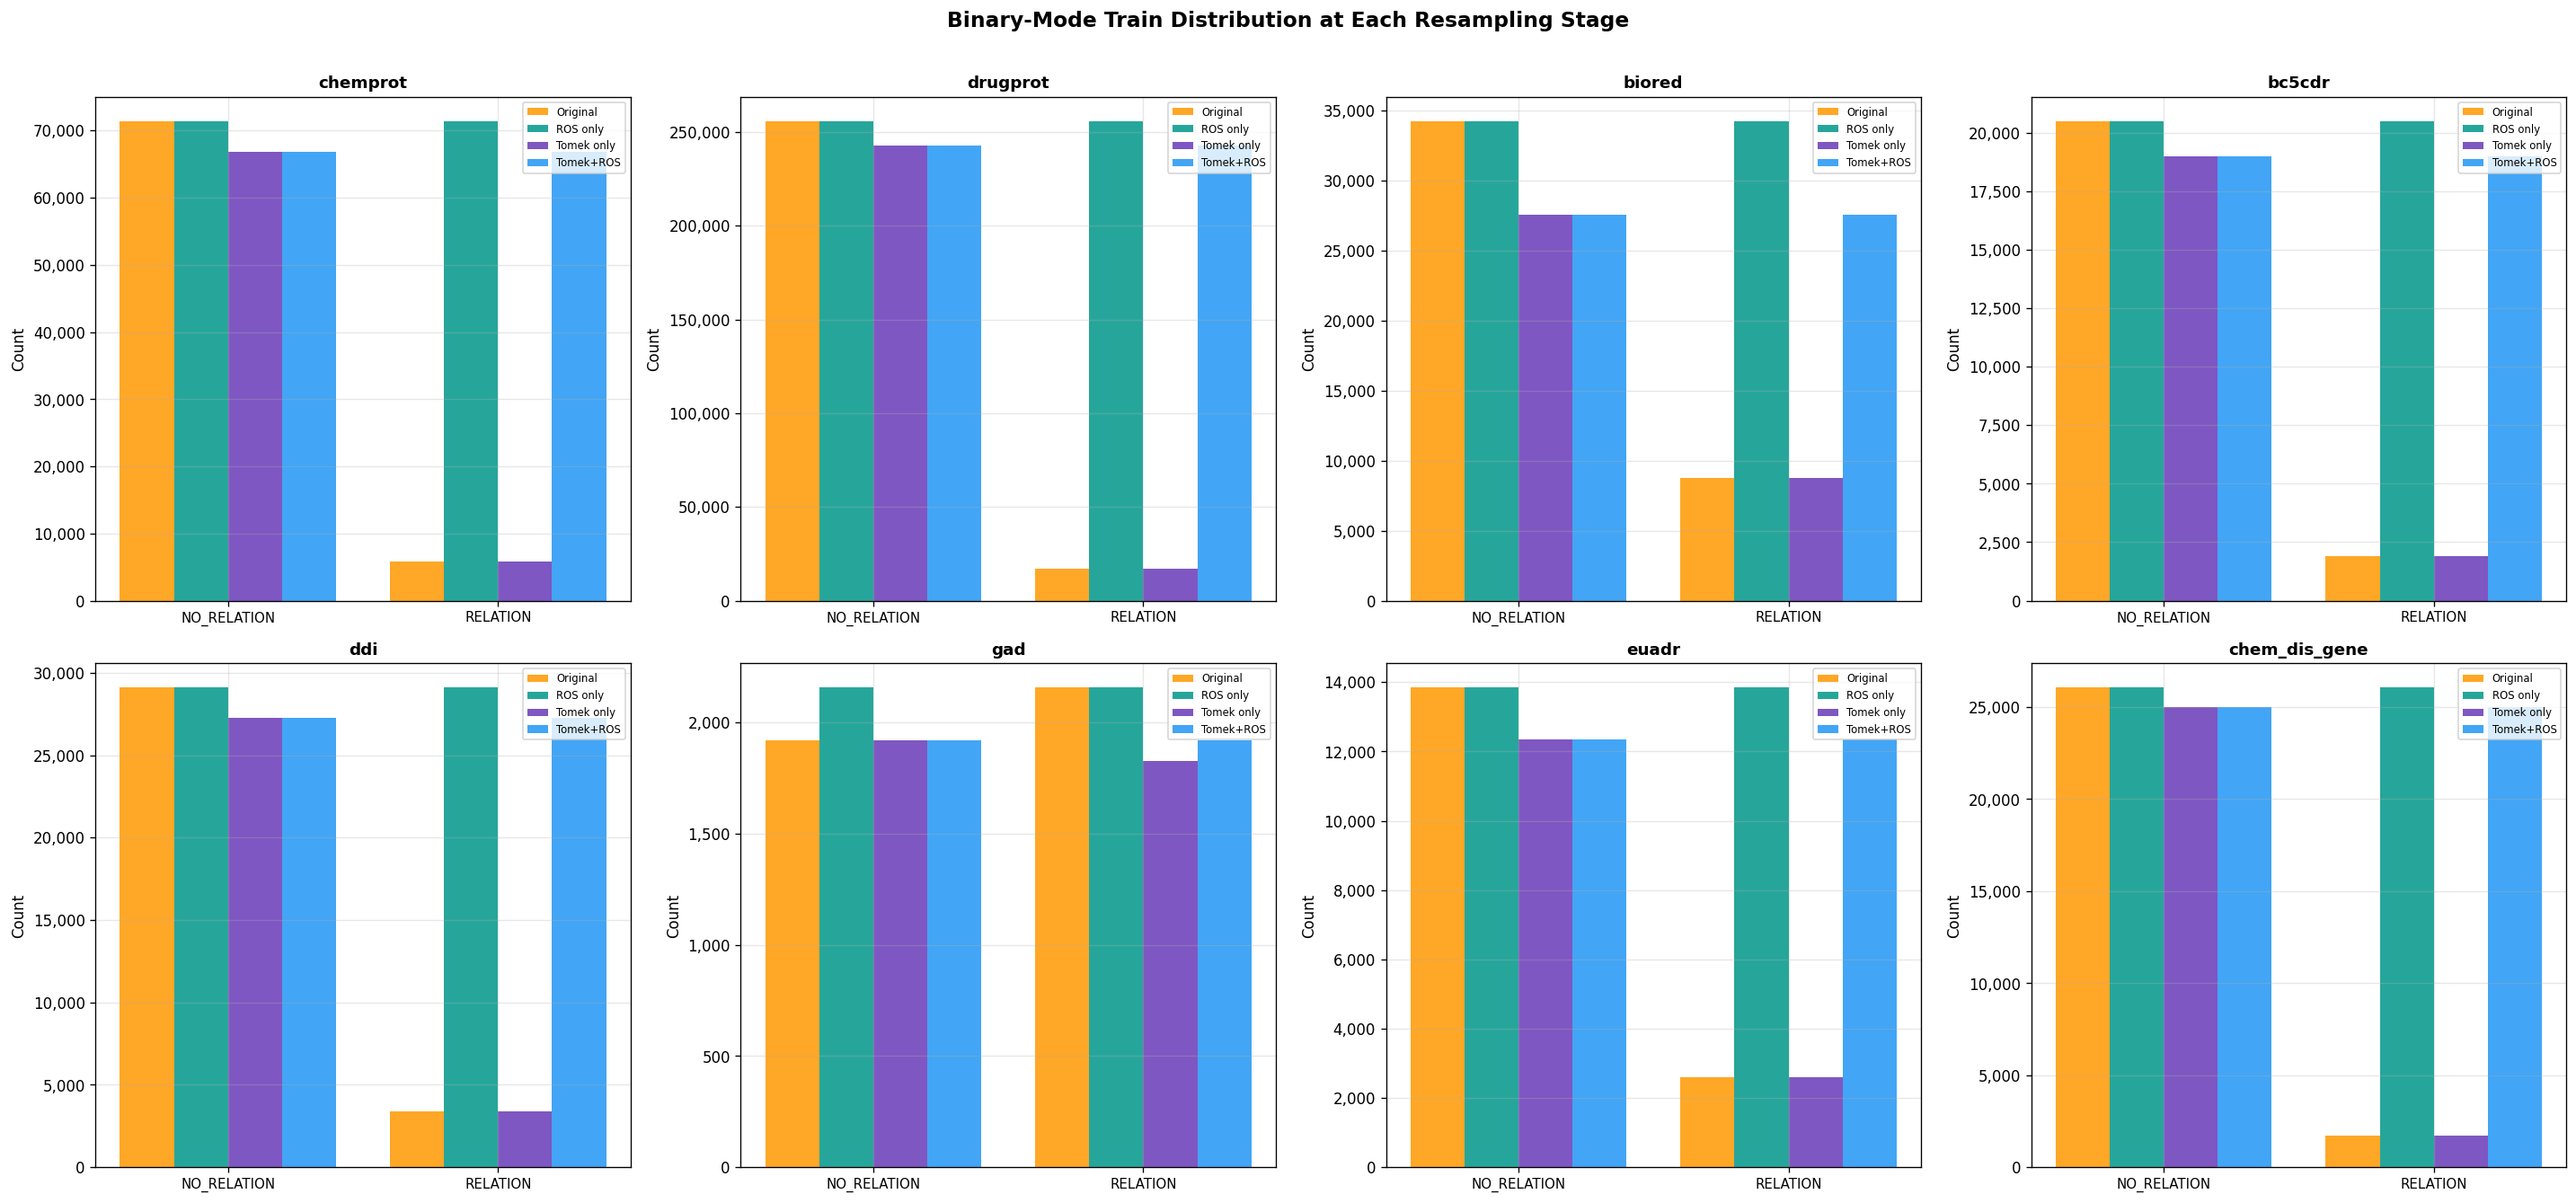

In [19]:
# Per-dataset 4-bar plot of binary class counts at each stage
fig, axes = plt.subplots(2, 4, figsize=(24, 11))
axes = axes.flatten()

stage_colors = {
    "Original":   "#FFA726",
    "ROS only":   "#26A69A",
    "Tomek only": "#7E57C2",
    "Tomek+ROS":  "#42A5F5",
}

for idx, ds_name in enumerate(DATASET_NAMES):
    ax = axes[idx]
    examples = binary_train.get(ds_name)
    if not examples:
        ax.set_visible(False)
        continue

    ros_only = random_oversample(examples, seed=42)
    tomek_only = binary_tomek_results.get(ds_name)
    tomek_ros = random_oversample(tomek_only, seed=42) if tomek_only is not None else None

    stages = {"Original": examples, "ROS only": ros_only}
    if tomek_only is not None:
        stages["Tomek only"] = tomek_only
        stages["Tomek+ROS"] = tomek_ros

    labels_axis = [BINARY_NEG, "RELATION"]
    n_stages = len(stages)
    bar_w = 0.8 / n_stages
    x = np.arange(len(labels_axis))

    for s_idx, (stage_name, exs) in enumerate(stages.items()):
        c = Counter(ex.label for ex in exs)
        counts = [c.get(l, 0) for l in labels_axis]
        offset = (s_idx - (n_stages - 1) / 2) * bar_w
        ax.bar(x + offset, counts, bar_w, label=stage_name, color=stage_colors[stage_name])

    ax.set_xticks(x)
    ax.set_xticklabels(labels_axis, fontsize=9)
    ax.set_title(ds_name, fontsize=11, fontweight="bold")
    ax.set_ylabel("Count")
    ax.legend(fontsize=7, loc="upper right")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))

for idx in range(len(DATASET_NAMES), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("Binary-Mode Train Distribution at Each Resampling Stage",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


In [20]:
# How much more (or less) does binary Tomek remove vs multi-class Tomek?
compare_rows = []
for ds_name in DATASET_NAMES:
    orig = all_data[ds_name]["splits"]["train"]
    if not orig:
        continue
    multi = tomek_results.get(ds_name)
    binr = binary_tomek_results.get(ds_name)
    if multi is None or binr is None:
        continue
    multi_removed = len(orig) - len(multi)
    binary_removed = len(orig) - len(binr)
    compare_rows.append({
        "Dataset": ds_name,
        "Train size": f"{len(orig):,}",
        "Multi-class Tomek removed": f"{multi_removed:,} ({multi_removed/len(orig)*100:.1f}%)",
        "Binary Tomek removed":      f"{binary_removed:,} ({binary_removed/len(orig)*100:.1f}%)",
        "Delta (binary − multi)":    f"{binary_removed - multi_removed:+,}",
    })

pd.DataFrame(compare_rows)


,Dataset,Train size,Multi-class Tomek removed,Binary Tomek removed,Delta (binary − multi)
0,chemprot,"77,252","4,553 (5.9%)","4,542 (5.9%)",-11
1,drugprot,"272,918","13,116 (4.8%)","13,062 (4.8%)",-54
2,biored,"43,038","6,698 (15.6%)","6,665 (15.5%)",-33
3,bc5cdr,"22,396","1,515 (6.8%)","1,515 (6.8%)",+0
4,ddi,"32,512","1,871 (5.8%)","1,870 (5.8%)",-1
5,gad,"4,077",332 (8.1%),332 (8.1%),+0
6,euadr,"16,431","1,518 (9.2%)","1,493 (9.1%)",-25
7,chem_dis_gene,"27,782","1,078 (3.9%)","1,069 (3.8%)",-9


## 8. Preprocessed Examples with Entity Markers

In [16]:
for ds_name in DATASET_NAMES:
    info = all_data[ds_name]
    ds = info["instance"]
    examples = info["splits"]["train"]
    if not examples:
        continue

    print(f"\n{'='*80}")
    print(f"  {ds_name.upper()}")
    print(f"  Labels: {', '.join(ds.label_names())}")
    print(f"  Negative label: {NEGATIVE_LABELS.get(ds_name)}")
    print(f"{'='*80}")

    neg_label = NEGATIVE_LABELS.get(ds_name)
    pos_examples = [ex for ex in examples if ex.label != neg_label][:2]
    neg_examples = [ex for ex in examples if ex.label == neg_label][:1]
    chosen = pos_examples + neg_examples

    for i, ex in enumerate(chosen, 1):
        has_entities = (ex.entity1_start != ex.entity1_end) or (ex.entity2_start != ex.entity2_end)
        kind = "NEGATIVE" if ex.label == neg_label else "POSITIVE"

        print(f"\n--- Example {i} ({kind}) ---")
        print(f"Label: {ex.label} (id={ex.label_id})")
        if has_entities:
            print(f"Entity 1: \"{ex.entity1}\" [{ex.entity1_type}] @ ({ex.entity1_start}, {ex.entity1_end})")
            print(f"Entity 2: \"{ex.entity2}\" [{ex.entity2_type}] @ ({ex.entity2_start}, {ex.entity2_end})")
        print(f"Sentence: {ex.text[:300]}{'...' if len(ex.text) > 300 else ''}")

        if has_entities:
            marked = apply_entity_markers(
                text=ex.text,
                e1_start=ex.entity1_start,
                e1_end=ex.entity1_end,
                e1_type=ex.entity1_type,
                e2_start=ex.entity2_start,
                e2_end=ex.entity2_end,
                e2_type=ex.entity2_type,
                strategy="typed_entity_marker_punct",
            )
            print(f"Marked:   {marked[:400]}{'...' if len(marked) > 400 else ''}")


  CHEMPROT
  Labels: Not, Upregulator, Downregulator, Agonist, Antagonist, Substrate
  Negative label: Not

--- Example 1 (POSITIVE) ---
Label: Downregulator (id=2)
Entity 1: "gefitinib" [CHEMICAL] @ (102, 111)
Entity 2: "Epidermal growth factor receptor" [GENE-Y] @ (0, 32)
Sentence: Epidermal growth factor receptor inhibitors currently under investigation include the small molecules gefitinib (Iressa, ZD1839) and erlotinib (Tarceva, OSI-774), as well as monoclonal antibodies such as cetuximab (IMC-225, Erbitux).
Marked:   @ E2-gene-y @ Epidermal growth factor receptor @ /E2-gene-y @  inhibitors currently under investigation include the small molecules # E1-chemical # gefitinib # /E1-chemical #  (Iressa, ZD1839) and erlotinib (Tarceva, OSI-774), as well as monoclonal antibodies such as cetuximab (IMC-225, Erbitux).

--- Example 2 (POSITIVE) ---
Label: Downregulator (id=2)
Entity 1: "Iressa" [CHEMICAL] @ (113, 119)
Entity 2: "Epidermal growth factor receptor" [GENE-Y] @ (0, 32)
Sentenc